In [65]:
import pandas as pd

# Load the Excel file
xls = pd.ExcelFile("E Commerce Dataset.xlsx")

# Checking sheet names
xls.sheet_names

['Data Dict', 'E Comm']

### The file contains two sheets:

`1. "Data Dict" – Likely a data dictionary explaining the columns`.

`2. "E Comm" – Likely the main dataset for churn prediction.`

I'll first inspect the "Data Dict" sheet to understand the column descriptions.

In [68]:
# Load the Data Dictionary sheet
data_dict = pd.read_excel(xls, sheet_name="Data Dict")

# Display the first few rows
data_dict.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3
0,NaN,Data,Variable,Discerption
1,NaN,E Comm,CustomerID,Unique customer ID
2,NaN,E Comm,Churn,Churn Flag
3,NaN,E Comm,Tenure,Tenure of customer in organization
4,NaN,E Comm,PreferredLoginDevice,Preferred login device of customer


`The data dictionary provides column names and their descriptions. but its have some formatting issues`

In [71]:
# Load the E Comm dataset
ecomm_data = pd.read_excel(xls, sheet_name="E Comm")

# Display the first few rows
ecomm_data.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


`The dataset includes various customer-related features. The target variable for churn prediction is "Churn", where 1 indicates a churned customer and 0 indicates retention.`

In [73]:
ecomm_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  NumberOfAddress   

In [74]:
ecomm_data.isnull().sum()


CustomerID                       0
Churn                            0
Tenure                         264
PreferredLoginDevice             0
CityTier                         0
WarehouseToHome                251
PreferredPaymentMode             0
Gender                           0
HourSpendOnApp                 255
NumberOfDeviceRegistered         0
PreferedOrderCat                 0
SatisfactionScore                0
MaritalStatus                    0
NumberOfAddress                  0
Complain                         0
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307
CashbackAmount                   0
dtype: int64

### Key Observations:
`1. Some columns have missing values (e.g., "Tenure", "HourSpendOnApp").`

`2. Features include demographic details (e.g., "Gender", "MaritalStatus"), behavioral metrics (e.g., "OrderCount", "CouponUsed"), and engagement data (e.g., "HourSpendOnApp", "DaySinceLastOrder").`

`3. Some categorical variables need encoding (e.g., "PreferredLoginDevice", "PreferredPaymentMode").`

C:\Users\Asus\AppData\Local\Temp\ipykernel_19892\280889189.py:9: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




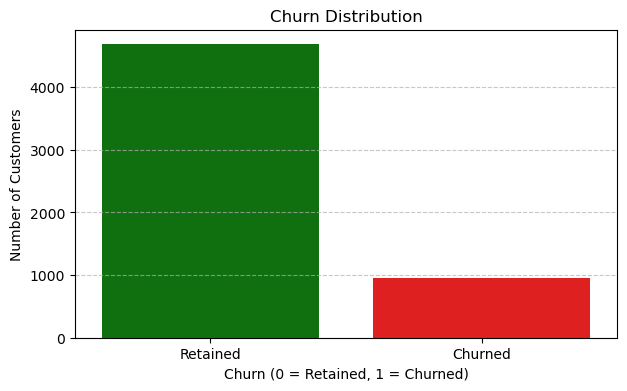

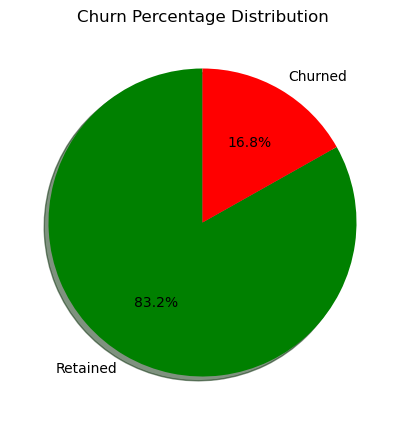

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count churn values
churn_counts = ecomm_data["Churn"].value_counts()

# 🔹 Bar Chart
plt.figure(figsize=(7, 4))
sns.barplot(x=churn_counts.index, y=churn_counts.values, palette=["green", "red"])
plt.xlabel("Churn (0 = Retained, 1 = Churned)")
plt.ylabel("Number of Customers")
plt.title("Churn Distribution")
plt.xticks([0, 1], ["Retained", "Churned"])
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

# 🔹 Pie Chart
plt.figure(figsize=(5, 5))
plt.pie(churn_counts, labels=["Retained", "Churned"], autopct="%1.1f%%", colors=["green", "red"], startangle=90, shadow=True)
plt.title("Churn Percentage Distribution")
plt.show()


C:\Users\Asus\AppData\Local\Temp\ipykernel_19892\1779399216.py:9: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




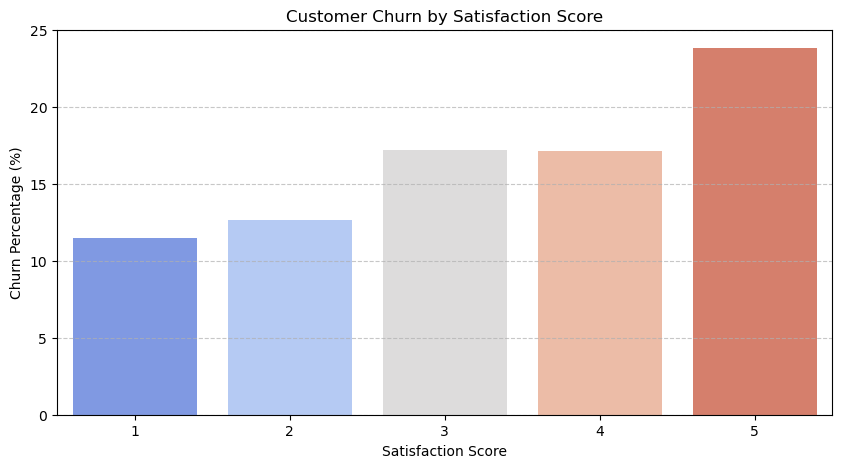

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by Satisfaction Score and calculate churn percentage
churn_by_satisfaction = ecomm_data.groupby("SatisfactionScore")["Churn"].mean() * 100

# Plot the results
plt.figure(figsize=(10, 5))
sns.barplot(x=churn_by_satisfaction.index, y=churn_by_satisfaction.values, palette="coolwarm")

plt.xlabel("Satisfaction Score")
plt.ylabel("Churn Percentage (%)")
plt.title("Customer Churn by Satisfaction Score")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


C:\Users\Asus\AppData\Local\Temp\ipykernel_19892\3684628643.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




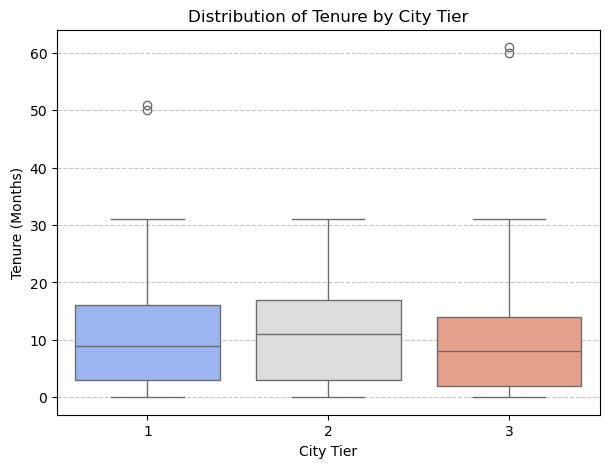

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))
sns.boxplot(x="CityTier", y="Tenure", data=ecomm_data, palette="coolwarm")

plt.xlabel("City Tier")
plt.ylabel("Tenure (Months)")
plt.title("Distribution of Tenure by City Tier")
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()


C:\Users\Asus\AppData\Local\Temp\ipykernel_19892\1224125952.py:9: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




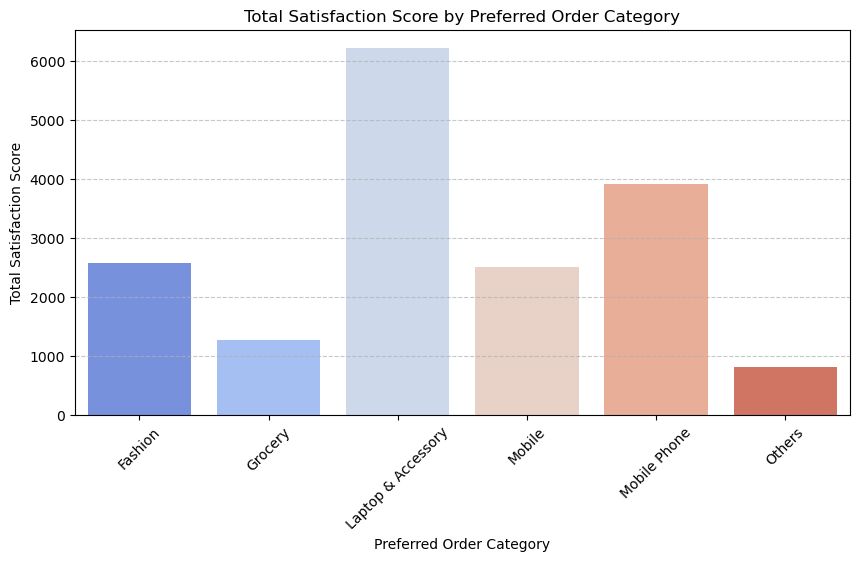

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by Preferred Order Category and sum Satisfaction Score
satisfaction_by_category = ecomm_data.groupby("PreferedOrderCat")["SatisfactionScore"].sum()

# 🔹 Bar Plot
plt.figure(figsize=(10, 5))
sns.barplot(x=satisfaction_by_category.index, y=satisfaction_by_category.values, palette="coolwarm")

plt.xlabel("Preferred Order Category")
plt.ylabel("Total Satisfaction Score")
plt.title("Total Satisfaction Score by Preferred Order Category")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()


In [59]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Drop CustomerID as it's not a useful feature
ecomm_data = ecomm_data.drop(columns=["CustomerID"])

# Handling categorical variables using Label Encoding
categorical_cols = ["PreferredLoginDevice", "PreferredPaymentMode", "Gender", "PreferedOrderCat", "MaritalStatus"]
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    ecomm_data[col] = le.fit_transform(ecomm_data[col].astype(str))  # Convert to string to handle NaNs
    label_encoders[col] = le

# Handling missing values with median imputation
imputer = SimpleImputer(strategy="median")
ecomm_data_imputed = pd.DataFrame(imputer.fit_transform(ecomm_data), columns=ecomm_data.columns)

# Splitting data into features (X) and target (y)
X = ecomm_data_imputed.drop(columns=["Churn"])
y = ecomm_data_imputed["Churn"]

# Splitting into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Training a RandomForestClassifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Making predictions
y_pred = model.predict(X_test)

# Evaluating the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print('-'*40)
print(accuracy)
print('-'*40)
print(report)
print('-'*40)


----------------------------------------
0.9804618117229129
----------------------------------------
              precision    recall  f1-score   support

         0.0       0.98      1.00      0.99       936
         1.0       0.98      0.90      0.94       190

    accuracy                           0.98      1126
   macro avg       0.98      0.95      0.96      1126
weighted avg       0.98      0.98      0.98      1126

----------------------------------------


In [81]:
from imblearn.over_sampling import SMOTE

# Drop CustomerID as it's not a useful feature
ecomm_data = ecomm_data.drop(columns=["CustomerID"])

# Handling categorical variables using Label Encoding
categorical_cols = ["PreferredLoginDevice", "PreferredPaymentMode", "Gender", "PreferedOrderCat", "MaritalStatus"]
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    ecomm_data[col] = le.fit_transform(ecomm_data[col].astype(str))  # Convert to string to handle NaNs
    label_encoders[col] = le

# Handling missing values with median imputation
imputer = SimpleImputer(strategy="median")
ecomm_data_imputed = pd.DataFrame(imputer.fit_transform(ecomm_data), columns=ecomm_data.columns)

# Splitting data into features (X) and target (y)
X = ecomm_data_imputed.drop(columns=["Churn"])
y = ecomm_data_imputed["Churn"]

# Handle class imbalance using SMOTE (Synthetic Minority Oversampling Technique)
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Splitting into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)

# Optimized RandomForestClassifier with class weighting
model = RandomForestClassifier(n_estimators=200, max_depth=15, min_samples_split=5, class_weight="balanced", random_state=42)
model.fit(X_train, y_train)

# Making probability predictions
y_prob = model.predict_proba(X_test)[:, 1]  # Get probabilities for class 1 (churn)

# Adjusting decision threshold for better recall (instead of default 0.5)
threshold = 0.4  # Lower threshold to catch more churners
y_pred = (y_prob >= threshold).astype(int)

# Evaluating the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print('-'*50)
print(f"Updated Accuracy: {accuracy:.4f}")
print('-'*50)

print("Updated Classification Report:\n", report)
print('-'*50)


--------------------------------------------------
Updated Accuracy: 0.9813
--------------------------------------------------
Updated Classification Report:
               precision    recall  f1-score   support

         0.0       0.99      0.97      0.98       937
         1.0       0.97      0.99      0.98       936

    accuracy                           0.98      1873
   macro avg       0.98      0.98      0.98      1873
weighted avg       0.98      0.98      0.98      1873

--------------------------------------------------


### Data Preprocessing & SMOTE:

`1. We drop the CustomerID column and encode categorical features with LabelEncoder.`

`2. Missing values are filled using the median.`

`3. SMOTE is applied to balance the classes before splitting the data.`

C:\Users\Asus\AppData\Local\Temp\ipykernel_19892\3037919856.py:15: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




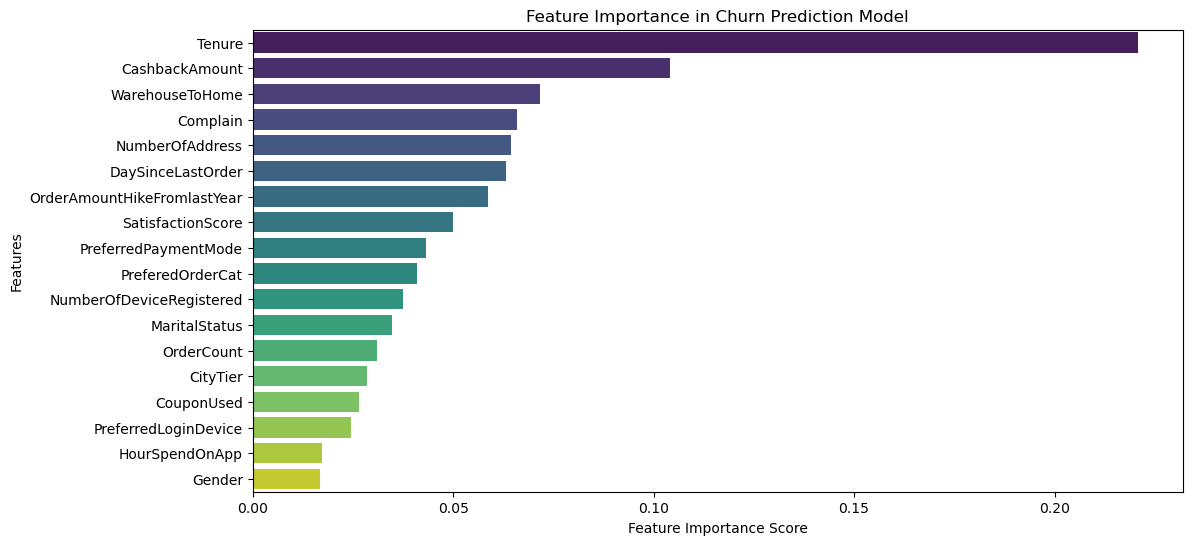

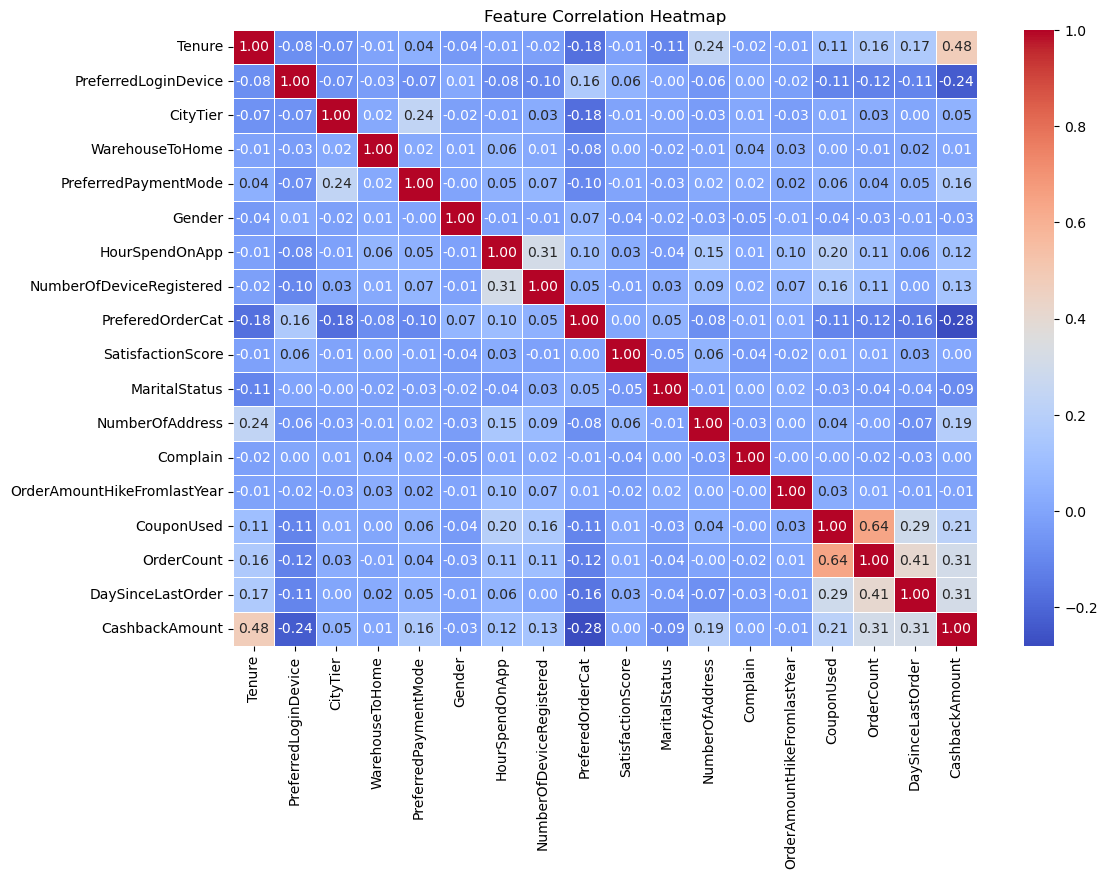

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Get feature importance from the trained RandomForest model
feature_importances = model.feature_importances_
feature_names = X_train.columns

# Create a DataFrame for visualization
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot Feature Importance
plt.figure(figsize=(12, 6))
sns.barplot(x=importance_df['Importance'], y=importance_df['Feature'], palette='viridis')
plt.xlabel("Feature Importance Score")
plt.ylabel("Features")
plt.title("Feature Importance in Churn Prediction Model")
plt.show()

# Plot Correlation Heatmap
plt.figure(figsize=(12, 8))
corr_matrix = X_train.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()


In [88]:
from sklearn.model_selection import GridSearchCV 

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 15, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "class_weight": ["balanced"]  # Use balanced class weighting
}

# Create the GridSearchCV object
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

# Fit grid search on the training data
grid_search.fit(X_train, y_train)

# Get best parameters and best estimator (model)
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_

# -----------------------------------
# 3. Evaluate the Best Model with Threshold Adjustment
# -----------------------------------
# Get probability predictions for class 1 (churn)
y_prob_best = best_model.predict_proba(X_test)[:, 1]

# Adjust decision threshold (default is 0.5, lower it to 0.4 to catch more churners)
threshold = 0.4
y_pred_best = (y_prob_best >= threshold).astype(int)

# Calculate accuracy and generate classification report
accuracy_best = accuracy_score(y_test, y_pred_best)
report_best = classification_report(y_test, y_pred_best)

# Print the results
print('-'*50)
print("Best Parameters from Grid Search:")
print(best_params)
print('-'*50)
print(f"Updated Accuracy: {accuracy_best:.4f}")
print('-'*50)
print("Updated Classification Report:\n", report_best)
print('-'*50)

--------------------------------------------------
Best Parameters from Grid Search:
{'class_weight': 'balanced', 'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
--------------------------------------------------
Updated Accuracy: 0.9829
--------------------------------------------------
Updated Classification Report:
               precision    recall  f1-score   support

         0.0       0.99      0.97      0.98       937
         1.0       0.97      0.99      0.98       936

    accuracy                           0.98      1873
   macro avg       0.98      0.98      0.98      1873
weighted avg       0.98      0.98      0.98      1873

--------------------------------------------------


### Hyperparameter Tuning:

`1. A parameter grid is defined for the RandomForestClassifier (including options for n_estimators, max_depth, etc.).`

`2. GridSearchCV runs a 3-fold cross-validation to select the best hyperparameters based on accuracy.`

`3. The best parameters and model are extracted.`

### Evaluation with Threshold Adjustment:

`1. The best model produces probabilities for class 1 (churn).`

`2. Instead of using the default 0.5 threshold, we lower it to 0.4 to improve recall on the churn class.`
    
`3. The updated accuracy and a detailed classification report are printed.`

In [90]:
import joblib

# Save the best model to a file
joblib.dump(best_model, "best_churn_model.pkl")
print("Model saved successfully!")

Model saved successfully!
